# Introduction to Data Science 2026

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)

(891, 12)


2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.shape)

(891, 9)


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [16]:
df['Deck'] = df['Cabin'].str[0]
df = df.drop(columns=['Cabin'])

In [17]:
print(df['Deck'].unique())

[nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [18]:
for col in ['Sex', 'Embarked', 'Deck']:
    df[col] = df[col].astype('category')
    df[col] = df[col].cat.codes

In [20]:
print(df['Deck'].unique())

[-1  2  4  6  3  0  1  5  7]


5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [21]:
import numpy as np

# 1. Volver a marcar los -1 como valores faltantes reales
df['Embarked'] = df['Embarked'].replace(-1, np.nan)
df['Deck'] = df['Deck'].replace(-1, np.nan)

# 2. Imputar variables continuas con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

# 3. Imputar variables categóricas con la moda
for col in ['Sex', 'Embarked', 'Deck', 'Pclass', 'SibSp', 'Parch']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Deck        0
dtype: int64

6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [6]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [23]:
# Exportar a CSV
df.to_csv('titanic_processed.csv', index=False)

# Exportar a JSON (lista de diccionarios, uno por pasajero)
df.to_json('titanic_processed.json', orient='records')

In [24]:
import json

with open('titanic_processed.json') as f:
    data = json.load(f)

print(data[0])

{'Survived': 0, 'Pclass': 3, 'Sex': 1, 'Age': 22.0, 'SibSp': 1, 'Parch': 0, 'Fare': 7.25, 'Embarked': 2.0, 'Deck': 2.0}


In [26]:
# Opción 1: usar print() en ambas
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())

Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Looking at the survival rates by group, two clear patterns emerge:

- **Sex**: women had a much higher survival rate (~74%) than men (~19%),
  consistent with the "women and children first" evacuation policy.
- **Passenger class**: survival rate decreases with class, from 63% in
  1st class to 47% in 2nd and 24% in 3rd, likely reflecting proximity
  to lifeboats and priority during evacuation.

Combining both factors would likely show that sex was the stronger
predictor of survival overall.

Study the records and try to see if there is any evident pattern in terms of chances of survival.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [28]:
categorical_cols = ['Sex', 'Pclass', 'Embarked', 'Deck', 'SibSp', 'Parch']
numerical_cols = ['Age', 'Fare']

# Moda de las categóricas
for col in categorical_cols:
    print(f"{col}: mode = {df[col].mode()[0]}")

# Mediana de las numéricas
for col in numerical_cols:
    print(f"{col}: median = {df[col].median()}")

Sex: mode = 1
Pclass: mode = 3
Embarked: mode = 2.0
Deck: mode = 2.0
SibSp: mode = 0
Parch: mode = 0
Age: median = 29.69911764705882
Fare: median = 14.4542


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [29]:
survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

def build_profile(subset):
    profile = {}
    for col in categorical_cols:
        profile[col] = subset[col].mode()[0]
    for col in numerical_cols:
        profile[col] = subset[col].median()
    return profile

average_survivor = build_profile(survivors)
average_non_survivor = build_profile(non_survivors)

print("Average survivor:", average_survivor)
print("Average non-survivor:", average_non_survivor)

Average survivor: {'Sex': np.int8(0), 'Pclass': np.int64(1), 'Embarked': np.float64(2.0), 'Deck': np.float64(2.0), 'SibSp': np.int64(0), 'Parch': np.int64(0), 'Age': np.float64(29.69911764705882), 'Fare': np.float64(26.0)}
Average non-survivor: {'Sex': np.int8(1), 'Pclass': np.int64(3), 'Embarked': np.float64(2.0), 'Deck': np.float64(2.0), 'SibSp': np.int64(0), 'Parch': np.int64(0), 'Age': np.float64(29.69911764705882), 'Fare': np.float64(10.5)}


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

In [31]:
display(survivors.describe())
display(non_survivors.describe())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
count,342.0,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,1.0,1.950292,0.318713,28.549778,0.473684,0.464912,48.395408,1.368421,2.163743
std,0.0,0.863321,0.466660,13.772498,0.708688,0.771712,66.596998,0.882510,0.904259
min,1.0,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.0,1.000000,0.000000,21.000000,0.000000,0.000000,12.475000,0.000000,2.000000
50%,1.0,2.000000,0.000000,29.699118,0.000000,0.000000,26.000000,2.000000,2.000000
75%,1.0,3.000000,1.000000,35.000000,1.000000,1.000000,57.000000,2.000000,2.000000
max,1.0,3.000000,1.000000,80.000000,4.000000,5.000000,512.329200,2.000000,6.000000


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
count,549.0,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,0.0,2.531876,0.852459,30.415100,0.553734,0.329690,22.117887,1.641166,2.043716
std,0.0,0.735805,0.354968,12.457370,1.288399,0.823166,31.388207,0.710081,0.580949
min,0.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,2.000000,1.000000,23.000000,0.000000,0.000000,7.854200,2.000000,2.000000
50%,0.0,3.000000,1.000000,29.699118,0.000000,0.000000,10.500000,2.000000,2.000000
75%,0.0,3.000000,1.000000,35.000000,1.000000,0.000000,26.000000,2.000000,2.000000
max,0.0,3.000000,1.000000,74.000000,8.000000,6.000000,263.000000,2.000000,7.000000


In [ ]:
# Are there real passengers similar to their own group's average profile?
similar_to_survivor = survivors[
    (survivors['Sex'] == average_survivor['Sex']) &
    (survivors['Pclass'] == average_survivor['Pclass'])
]
print(f"{len(similar_to_survivor)} survivors match the survivor profile (Sex + Pclass)")

# Are there non-survivors similar to the survivor's average profile?
unexpected = non_survivors[
    (non_survivors['Sex'] == average_survivor['Sex']) &
    (non_survivors['Pclass'] == average_survivor['Pclass'])
]
print(f"{len(unexpected)} non-survivors match the survivor profile (Sex + Pclass) — unexpected cases")

The average profiles represent the "Sex + Pclass" trend well: 91 out of
342 survivors (27%) exactly match the survivor profile (female, 1st class),
while only 3 non-survivors share that same profile. This shows the trend
is strong, even if the "average" doesn't capture every survivor.

However, looking at describe(), the average profile represents Fare
poorly: the standard deviation among survivors (66.6) is even higher than
their mean (48.4), meaning fares varied a lot within the group. A single
average fare doesn't capture a "typical" survivor well.

4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

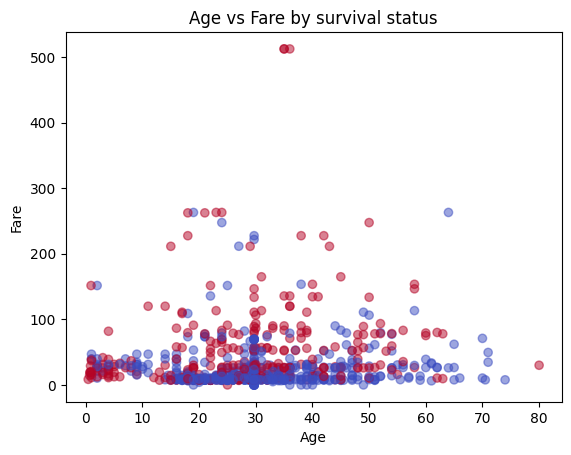

In [33]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Fare'], c=df['Survived'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare by survival status')
plt.show()

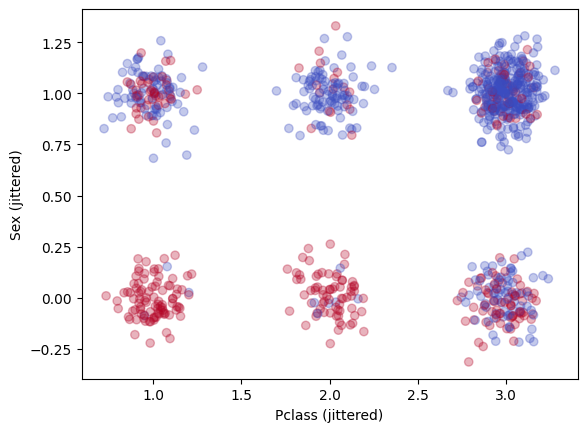

In [34]:
import numpy as np

jitter_strength = 0.1
x_jittered = df['Pclass'] + np.random.normal(0, jitter_strength, size=len(df))
y_jittered = df['Sex'] + np.random.normal(0, jitter_strength, size=len(df))

plt.scatter(x_jittered, y_jittered, c=df['Survived'], cmap='coolwarm', alpha=0.3)
plt.xlabel('Pclass (jittered)')
plt.ylabel('Sex (jittered)')
plt.show()

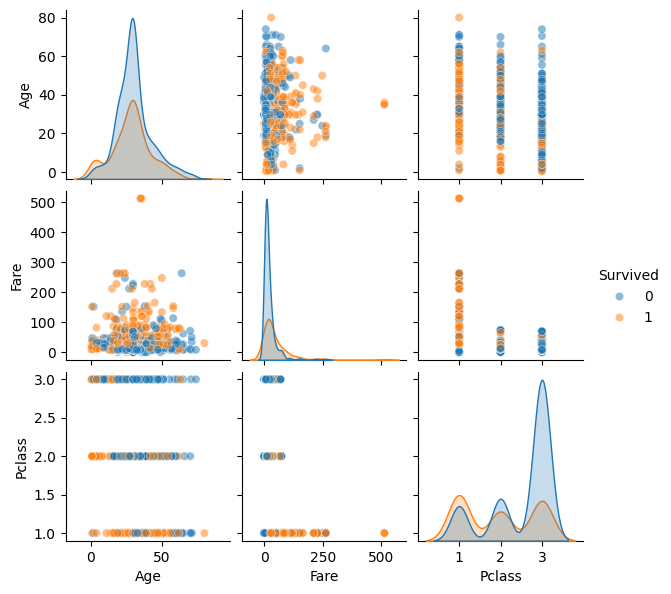

In [35]:
import seaborn as sns

sns.pairplot(df, vars=['Age', 'Fare', 'Pclass'], hue='Survived', height=2, plot_kws={'alpha': 0.5})
plt.show()

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

In [36]:
df_original = pd.read_csv('train.csv')
print(df_original.isnull().sum())
print(df_original.isnull().sum() / len(df_original) * 100)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


The proportion of missing values varies a lot between features: `Age` was
missing in ~20% of rows, `Embarked` in only ~0.2%, but `Cabin` (→ `Deck`)
was missing in ~77% of rows.

Using `dropna()` instead of imputing would have removed the vast majority
of the dataset, since almost 8 out of 10 passengers had no cabin recorded.
This would make the analysis impractical and would waste a lot of usable
information from the other columns.

Imputing with the mean/mode preserves the full sample size, but it comes
with a trade-off: it artificially reduces the variability of the imputed
column (all missing values collapse into a single "typical" value), which
can weaken any real signal that variable carries.

This is especially problematic for `Deck`, since the missingness is
likely not random: passengers in lower classes were less likely to have
a recorded cabin, simply because they didn't have individually assigned
cabins. Imputing with the mode hides this relationship instead of
preserving it — the fact that the cabin was missing was informative in
itself, and that information is lost after imputation.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [37]:
from collections import Counter
import re

with open('pos.txt', 'r', encoding='utf-8') as f:
    pos_text = f.read()

with open('neg.txt', 'r', encoding='utf-8') as f:
    neg_text = f.read()

pos_words = re.findall(r'\b\w+\b', pos_text.lower())
neg_words = re.findall(r'\b\w+\b', neg_text.lower())

pos_counts = Counter(pos_words)
neg_counts = Counter(neg_words)

print("Top 15 words in positive reviews:")
print(pos_counts.most_common(15))

print("\nTop 15 words in negative reviews:")
print(neg_counts.most_common(15))

Top 15 words in positive reviews:
[('great', 437282), ('work', 427780), ('use', 345234), ('good', 291458), ('fit', 273506), ('instal', 229391), ('product', 210085), ('perfect', 192155), ('look', 181401), ('just', 180421), ('like', 175725), ('easi', 162864), ('light', 148329), ('car', 147268), ('price', 144891)]

Top 15 words in negative reviews:
[('work', 39998), ('use', 37244), ('fit', 31294), ('product', 24394), ('just', 23582), ('light', 23024), ('like', 20685), ('time', 19665), ('look', 18824), ('instal', 18707), ('did', 18447), ('good', 17295), ('dont', 17136), ('buy', 16885), ('car', 16715)]


There is a lot of overlap between the most common words in positive and
negative reviews (e.g. "work", "use", "fit", "product", "just", "light",
"like", "look", "instal", "car"). These are general terms related to the
domain of the reviews (likely automotive products), not to sentiment.

Only a few words seem to actually indicate sentiment: "great", "good",
"perfect", "easi[y]" in positive reviews, and "dont" in negative ones.
Overall, raw word frequency is not a good indicator of sentiment on its
own, since the most frequent words mostly reflect what the reviews are
about, not how the reviewer felt about it.

2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [pos_text, neg_text]  # index 0 = positive, index 1 = negative

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

print(tfidf_matrix.shape)  # should be (2, m)

(2, 236553)


3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [40]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['pos', 'neg'],
    columns=feature_names
)

top_pos = df_tfidf.loc['pos'].sort_values(ascending=False).head(15)
top_neg = df_tfidf.loc['neg'].sort_values(ascending=False).head(15)

print("Top 15 TF-IDF words - positive:")
print(top_pos)

print("\nTop 15 TF-IDF words - negative:")
print(top_neg)

Top 15 TF-IDF words - positive:
great      0.364993
work       0.357062
use        0.288162
good       0.243276
fit        0.228292
instal     0.191470
product    0.175355
perfect    0.160389
look       0.151413
just       0.150595
like       0.146675
easi       0.135940
light      0.123808
car        0.122923
price      0.120939
Name: pos, dtype: float64

Top 15 TF-IDF words - negative:
work       0.301136
use        0.280401
fit        0.235605
product    0.183657
just       0.177543
light      0.173342
like       0.155732
time       0.148053
look       0.141721
instal     0.140841
did        0.138883
good       0.130210
dont       0.129013
buy        0.127123
car        0.125843
Name: neg, dtype: float64


The TF-IDF top words are almost identical to the raw word-count top words
from part 1 ("work", "use", "fit", "product", "just", "light", "like",
"look", "instal", "car" appear in both). This suggests TF-IDF did not
work as well as expected here.

The reason is likely the small number of documents: with only 2
documents (the whole positive file and the whole negative file), the
IDF term has very little discriminating power. IDF is meant to penalize
words that appear in many documents, but with just 2 possible documents,
almost every common word already appears in both, so it gets a low IDF
score in both classes — similar to how it would get penalized under raw
frequency alone.

TF-IDF would likely be more effective if each individual review was
treated as a separate document, rather than concatenating all reviews of
each class into a single large text. That would let IDF actually detect
words that are distinctive of specific reviews, rather than just
distinguishing between two enormous merged documents.

4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

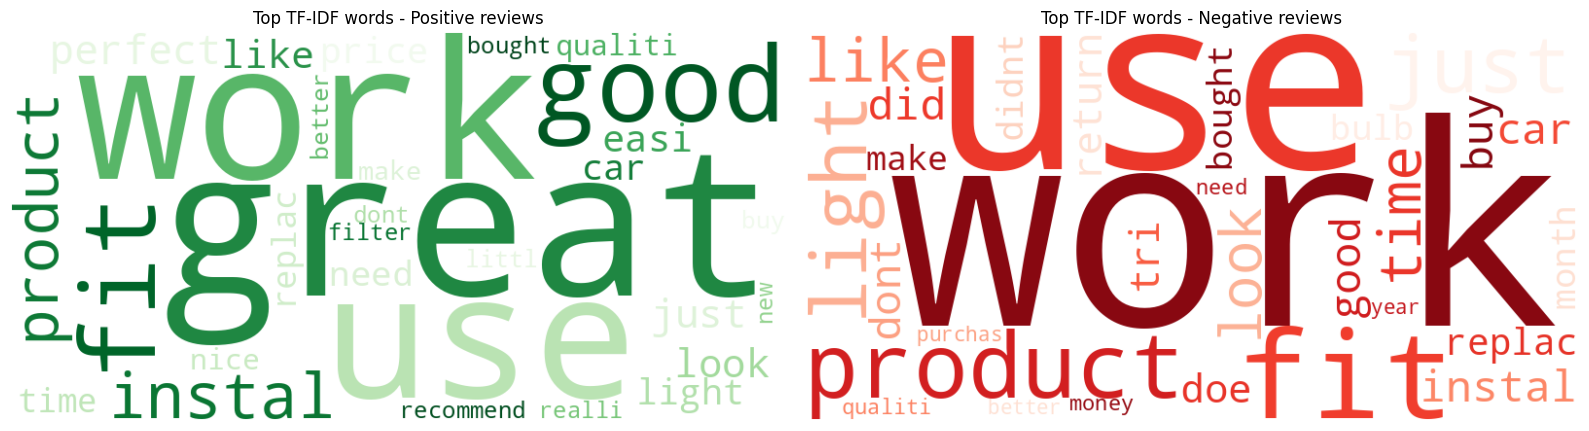

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Take a larger set of top words for a richer word cloud
top_pos_30 = df_tfidf.loc['pos'].sort_values(ascending=False).head(30)
top_neg_30 = df_tfidf.loc['neg'].sort_values(ascending=False).head(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens')
wc_pos.generate_from_frequencies(top_pos_30.to_dict())
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Top TF-IDF words - Positive reviews')

wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds')
wc_neg.generate_from_frequencies(top_neg_30.to_dict())
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Top TF-IDF words - Negative reviews')

plt.tight_layout()
plt.show()

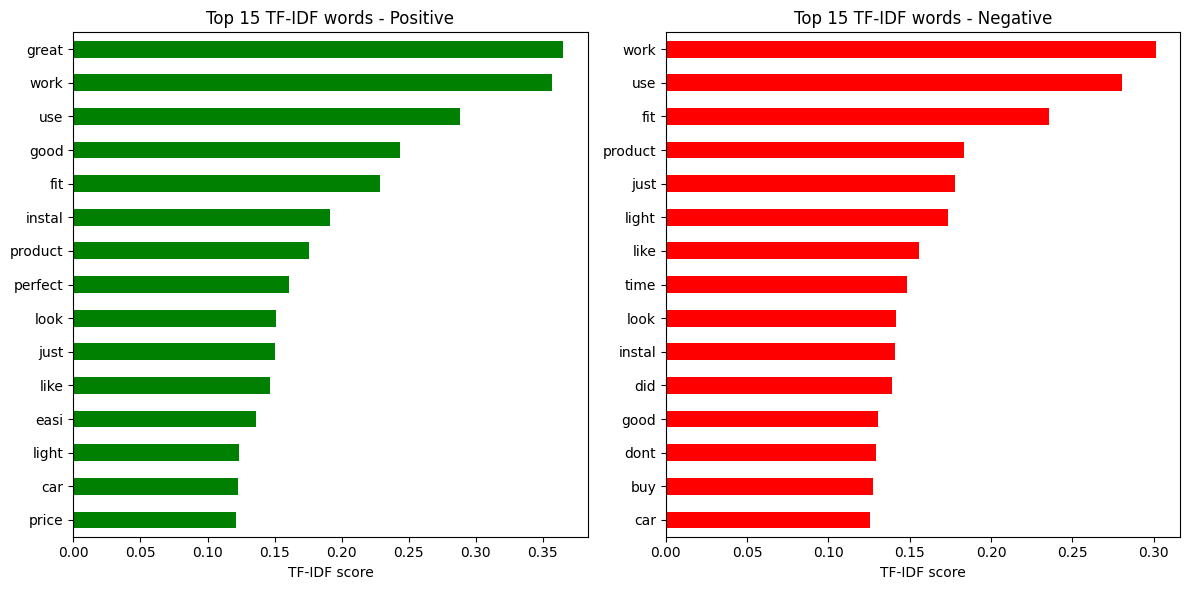

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

top_pos.sort_values().plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 15 TF-IDF words - Positive')
axes[0].set_xlabel('TF-IDF score')

top_neg.sort_values().plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 15 TF-IDF words - Negative')
axes[1].set_xlabel('TF-IDF score')

plt.tight_layout()
plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**